In [181]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [182]:
df = pd.read_csv('concrete_data.csv')

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [184]:
df.sample()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
494,387.0,20.0,94.0,157.0,14.3,938.0,845.0,56,56.34


In [185]:
result = {}

# Starting with sample regression

In [186]:
X = df.drop(columns='Strength')
y = df['Strength']

In [187]:
from sklearn.model_selection import train_test_split, cross_val_score

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=111)

In [189]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [190]:
lr = LinearRegression()

In [191]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [192]:
r2_score(y_test,lr.predict(X_test))

0.6151894904144969

In [193]:
lr_cr = LinearRegression()
np.mean(cross_val_score(lr_cr,X,y,scoring='r2', ))

np.float64(0.46099404916628667)

### Seaborn Plotting Distortions: `displot` vs. `histplot`

#### The Problem

When looping through dataframe columns to visualize distributions alongside probability plots using `plt.subplot()`, your subplots may render sequentially as stacked vertical figures rather than sitting side-by-side. The notebook output becomes unnecessarily long, rendering a giant wall of figures.

```python
# BUGGY CODE: displot overrides subplot grids
for col in X_train.columns:
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    sns.displot(X_train[col])     # <- CRITICAL ERROR: Figure-level function
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)
    plt.show()

```

#### Why It Happens

Seaborn splits its visualization functions into two distinct operational categories:

1. **Figure-Level Functions (`sns.displot`, `sns.catplot`, `sns.lmplot`):** These functions control their own matplotlib figures via an underlying grid canvas object (like a `FacetGrid`). They completely ignore existing `plt.subplot()` directives and spin up a brand new independent canvas window, breaking your multi-plot grid assignments.
2. **Axes-Level Functions (`sns.histplot`, `sns.getplot`, `sns.boxplot`):** These behave like standard matplotlib operations. They draw cleanly onto the currently active subplot axes (`plt.gca()`) and respect any multi-plot grids you have set up.

#### The Solution

Swap out the figure-level `sns.displot()` for the axes-level `sns.histplot()`. Pair it with `plt.tight_layout()` to automatically prevent text elements (titles, axis tick labels) from overlapping.

```python
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Correct implementation for side-by-side plots
for col in X_train.columns:
    plt.figure(figsize=(12, 4.5))
    
    # Left Subplot: Axes-level distribution
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True, color='#2b5c8f')
    plt.title(f"{col} - Distribution")
    
    # Right Subplot: Q-Q plot
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"{col} - Probability Plot")
    
    plt.tight_layout()
    plt.show()

```

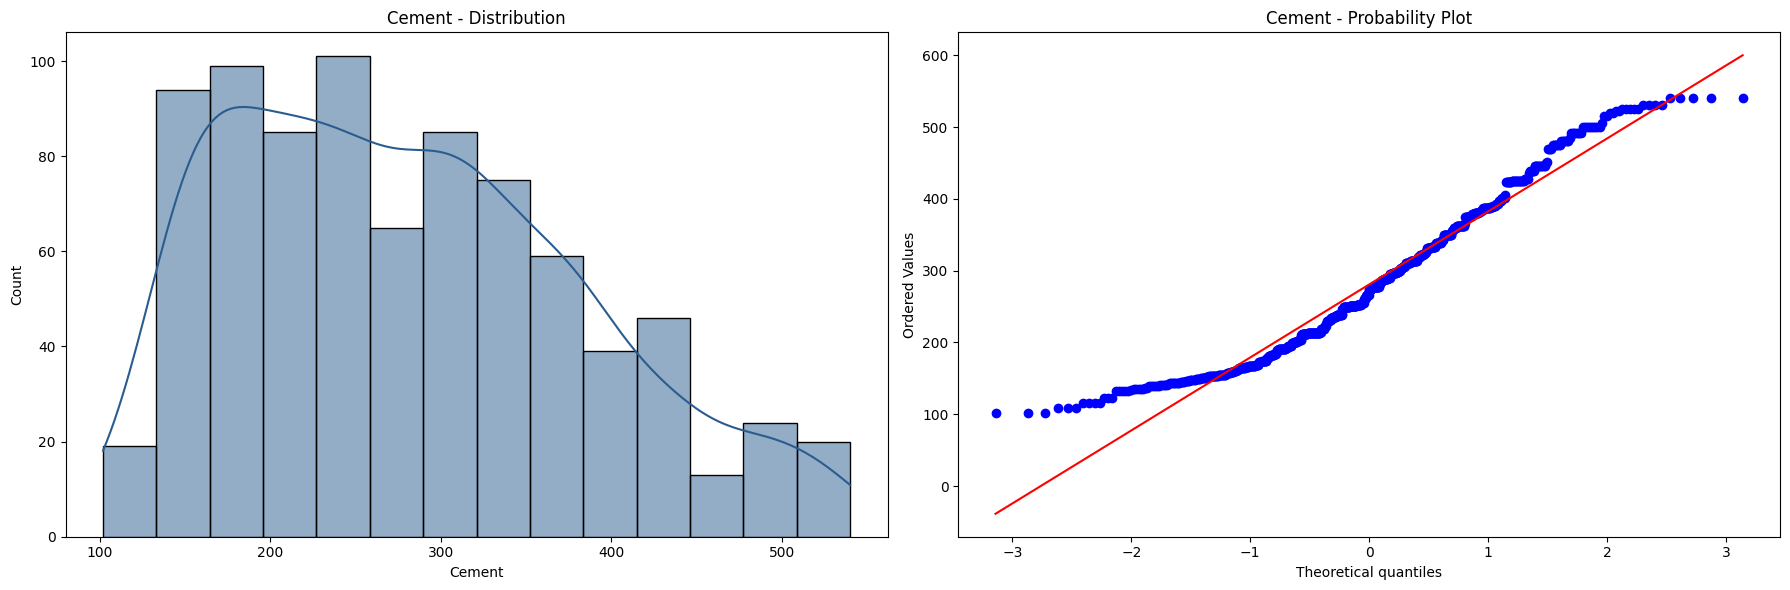

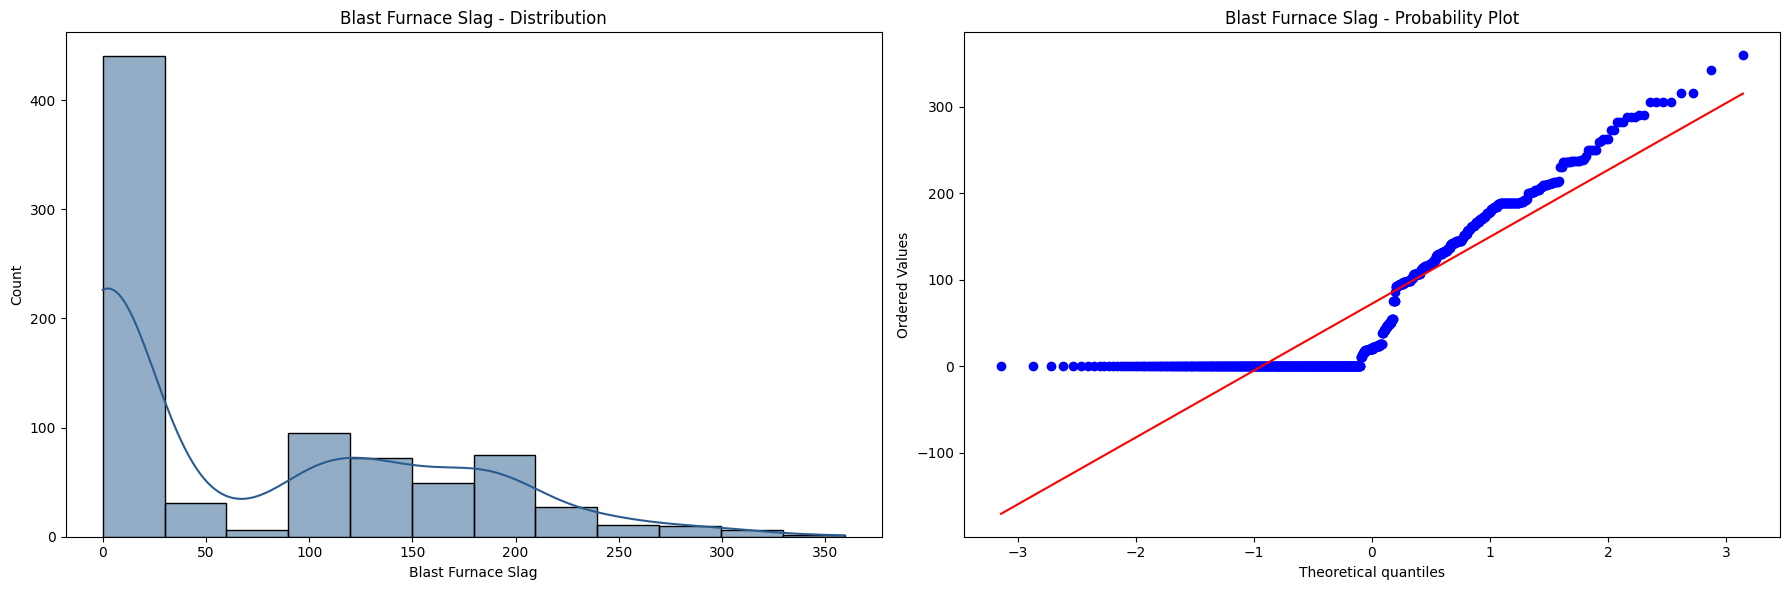

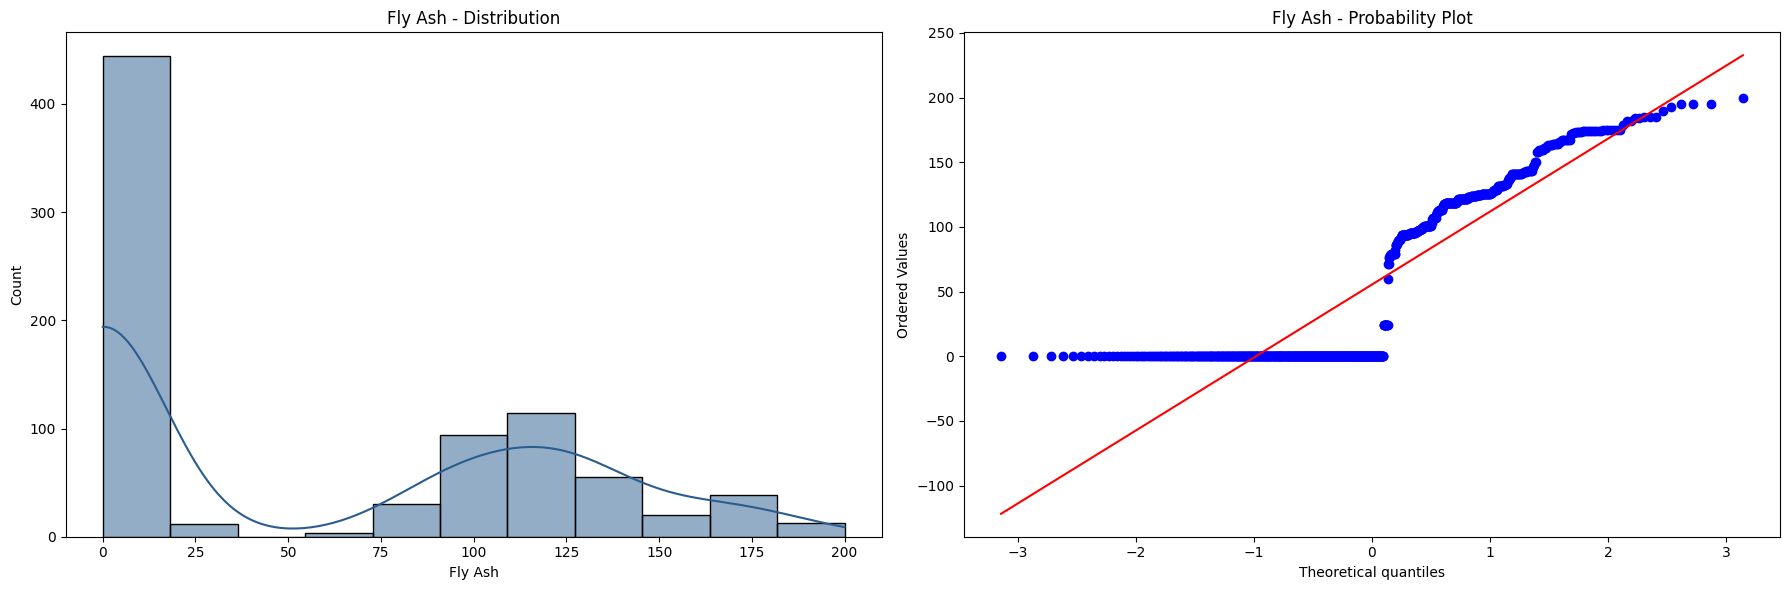

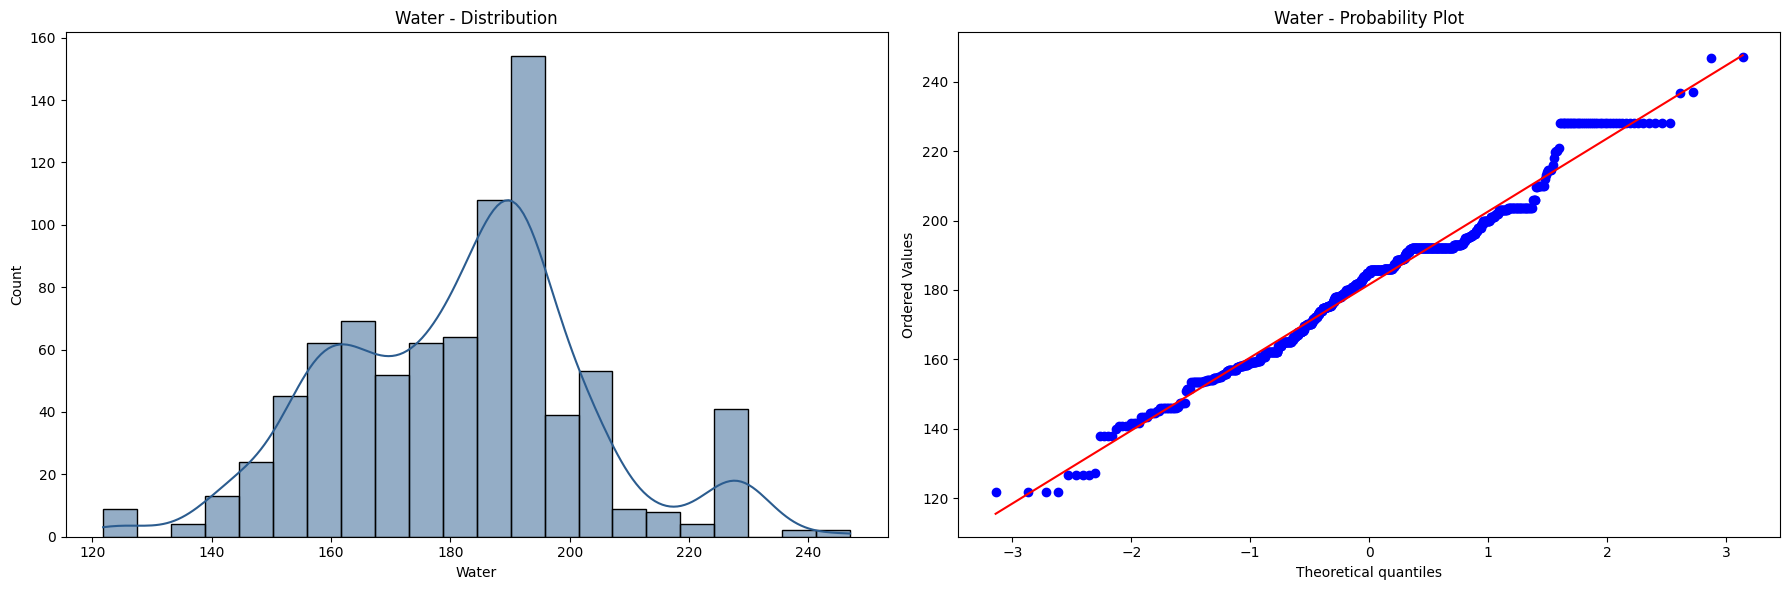

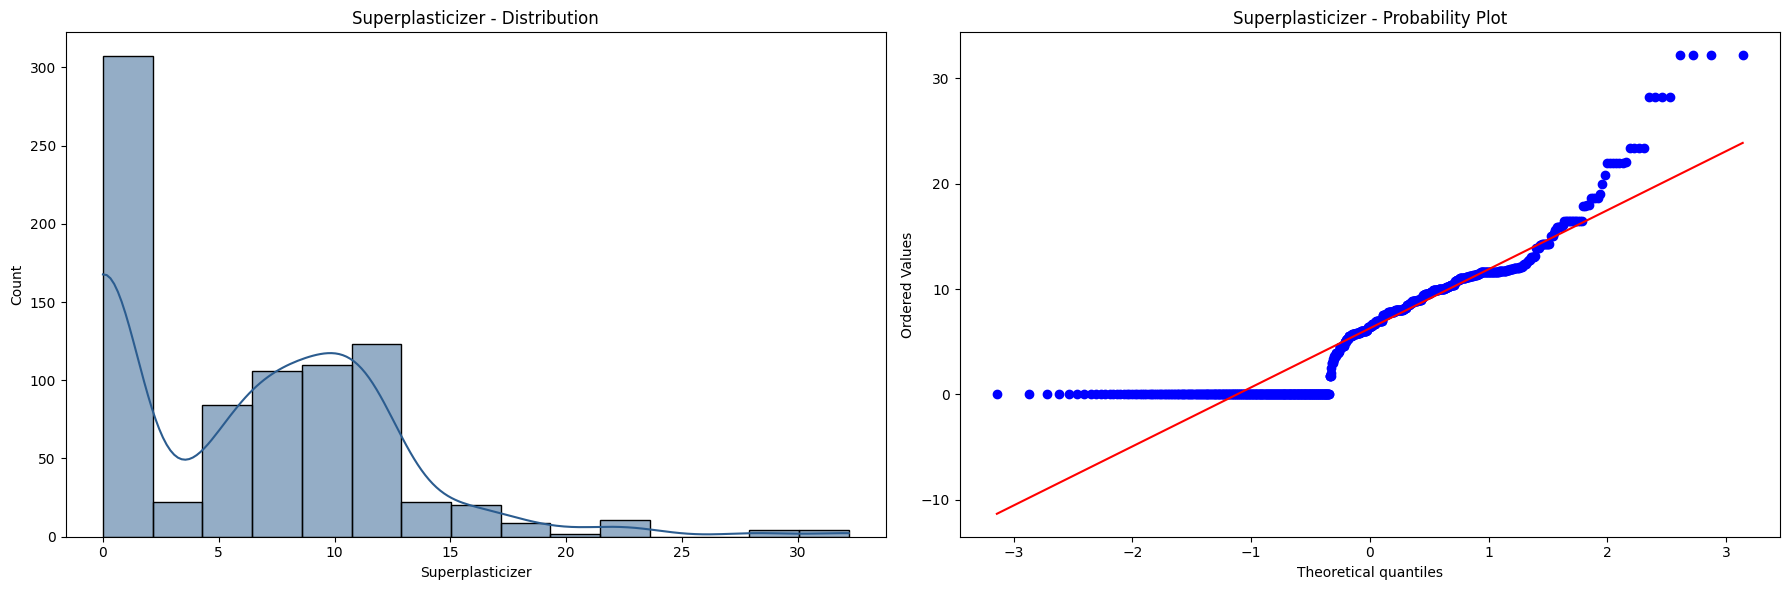

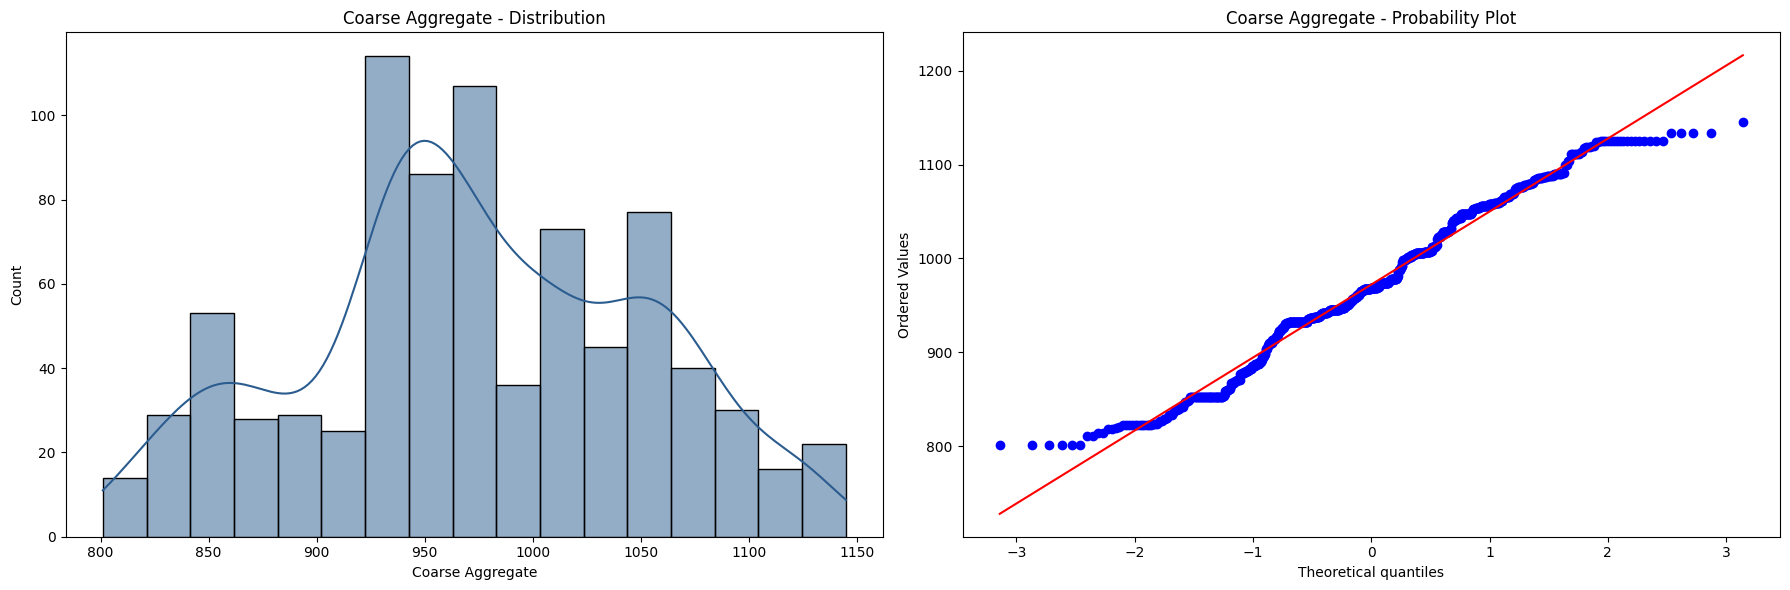

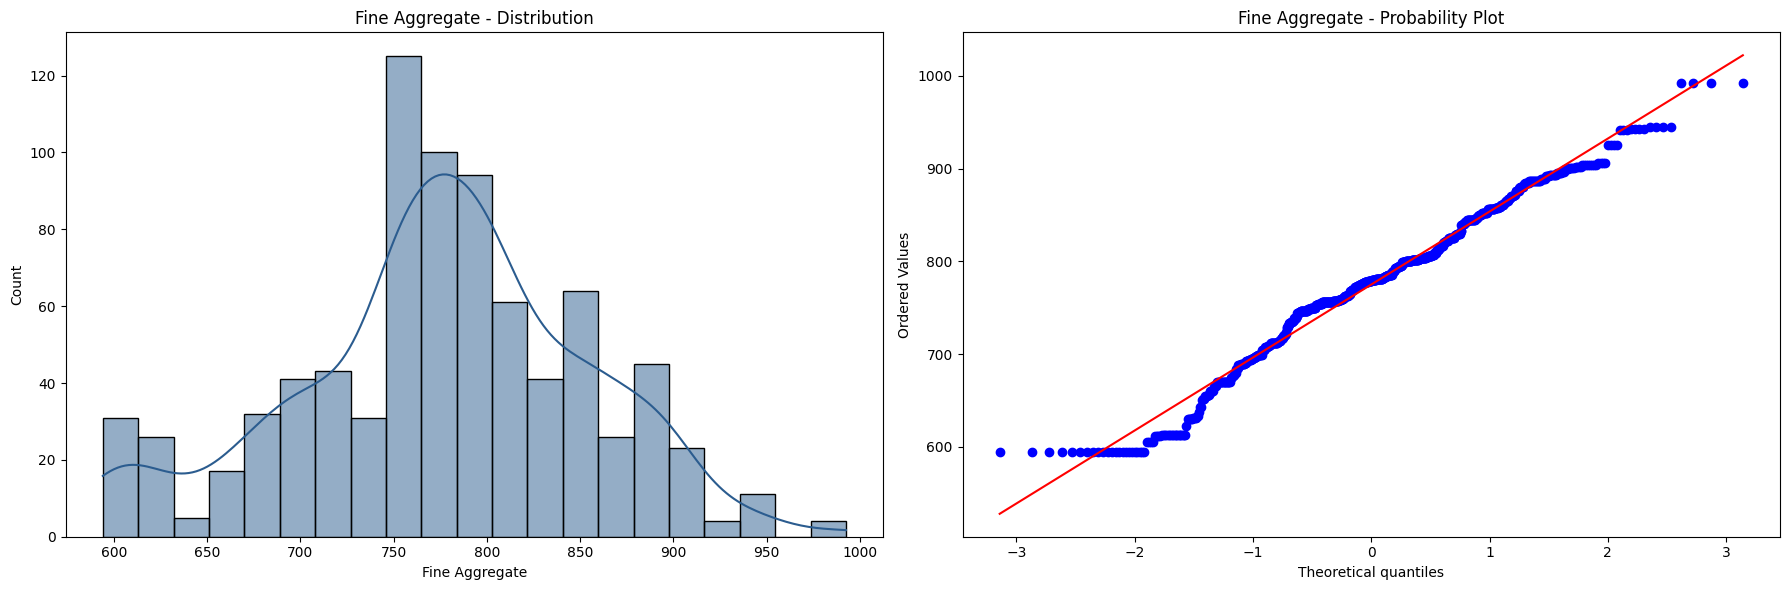

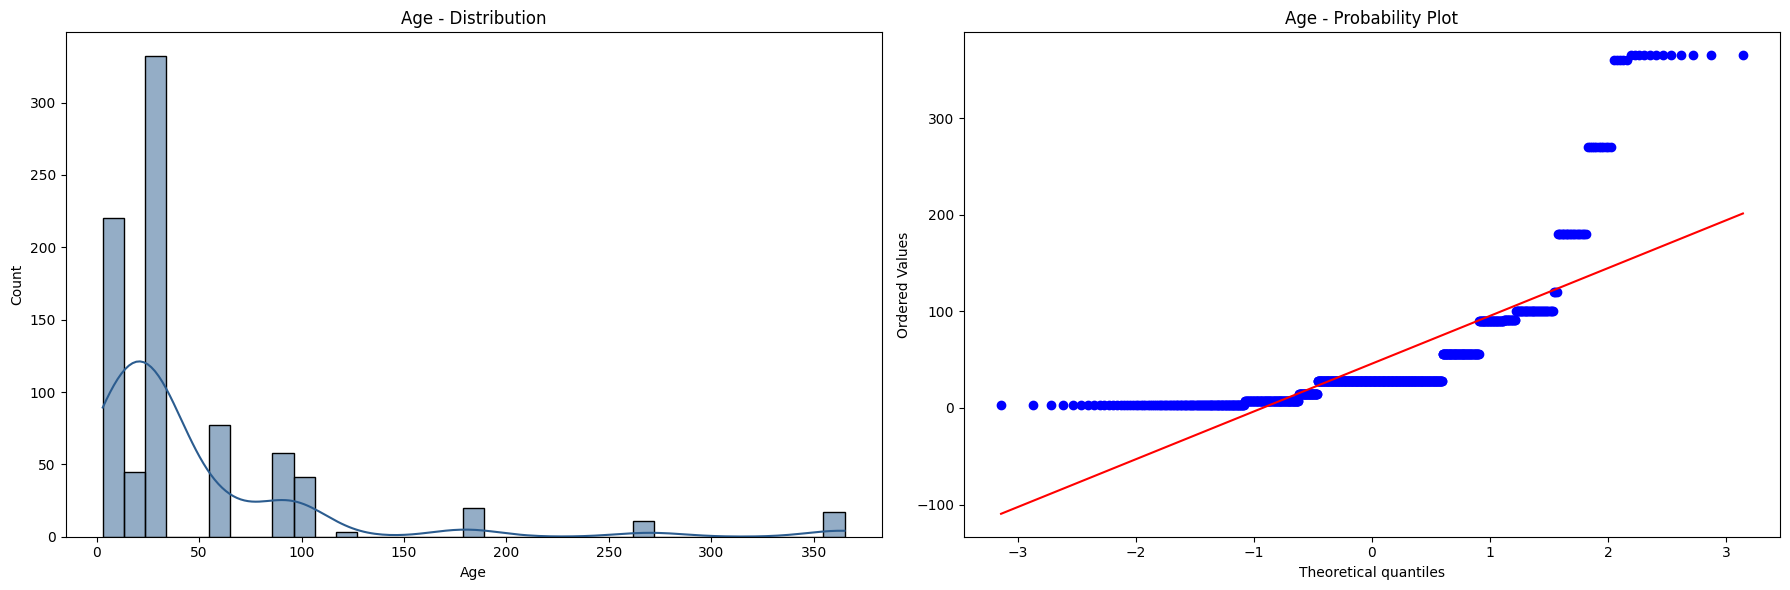

In [194]:
# Plotting the distplots without any transformation
# There is somethinng which broke and fixed in this code please read above markdown
for col in X_train.columns:
    plt.figure(figsize=(18, 6))
    
    # Left Subplot: Axes-level distribution
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True, color='#2b5c8f')
    plt.title(f"{col} - Distribution")
    
    # Right Subplot: Q-Q plot
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"{col} - Probability Plot")
    
    plt.tight_layout()
    plt.show()

In [195]:
result['No Transform'] = [r2_score(y_test,lr.predict(X_test)),np.mean(cross_val_score(lr_cr,X,y,scoring='r2' ))]

# Box Cox Transform

In [196]:
df.describe() # to check if values are positive or not

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [197]:
(X_train+0.000001).describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000
mean,280.615656,72.410923,55.511287,181.572938,6.265656,972.211409,775.062744,45.831312
std,103.348465,85.662552,64.158867,21.175003,6.004435,78.257890,79.143931,64.356026
min,102.000001,0.000001,0.000001,121.800001,0.000001,801.000001,594.000001,3.000001
25%,194.700001,0.000001,0.000001,164.900001,0.000001,932.000001,734.300001,7.000001
50%,272.700001,20.000001,0.000001,185.000001,6.400001,968.000001,779.300001,28.000001
75%,350.000001,141.300001,118.300001,192.000001,10.300001,1031.500001,825.000001,56.000001
max,540.000001,359.400001,200.000001,247.000001,32.200001,1145.000001,992.600001,365.000001


In [198]:
from sklearn.preprocessing import PowerTransformer

In [199]:
box_cox =PowerTransformer(method = 'box-cox')

In [200]:
X_train_transformed = box_cox.fit_transform(X_train+0.000001)
X_test_transformed = box_cox.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':box_cox.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.181452
1,Blast Furnace Slag,0.022754
2,Fly Ash,-0.025427
3,Water,0.798870
4,Superplasticizer,0.100940
5,Coarse Aggregate,1.170727
6,Fine Aggregate,1.791055
7,Age,0.037506


In [201]:
# Applying linear regression on thhe box-cox transformed data
lr = LinearRegression()

lr.fit(X_train_transformed,y_train)
y_pred_boxcox = lr.predict(X_test_transformed)
r2_score(y_test,y_pred_boxcox)

0.8095202998599988

In [202]:
# analysing cross val score 

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434355)

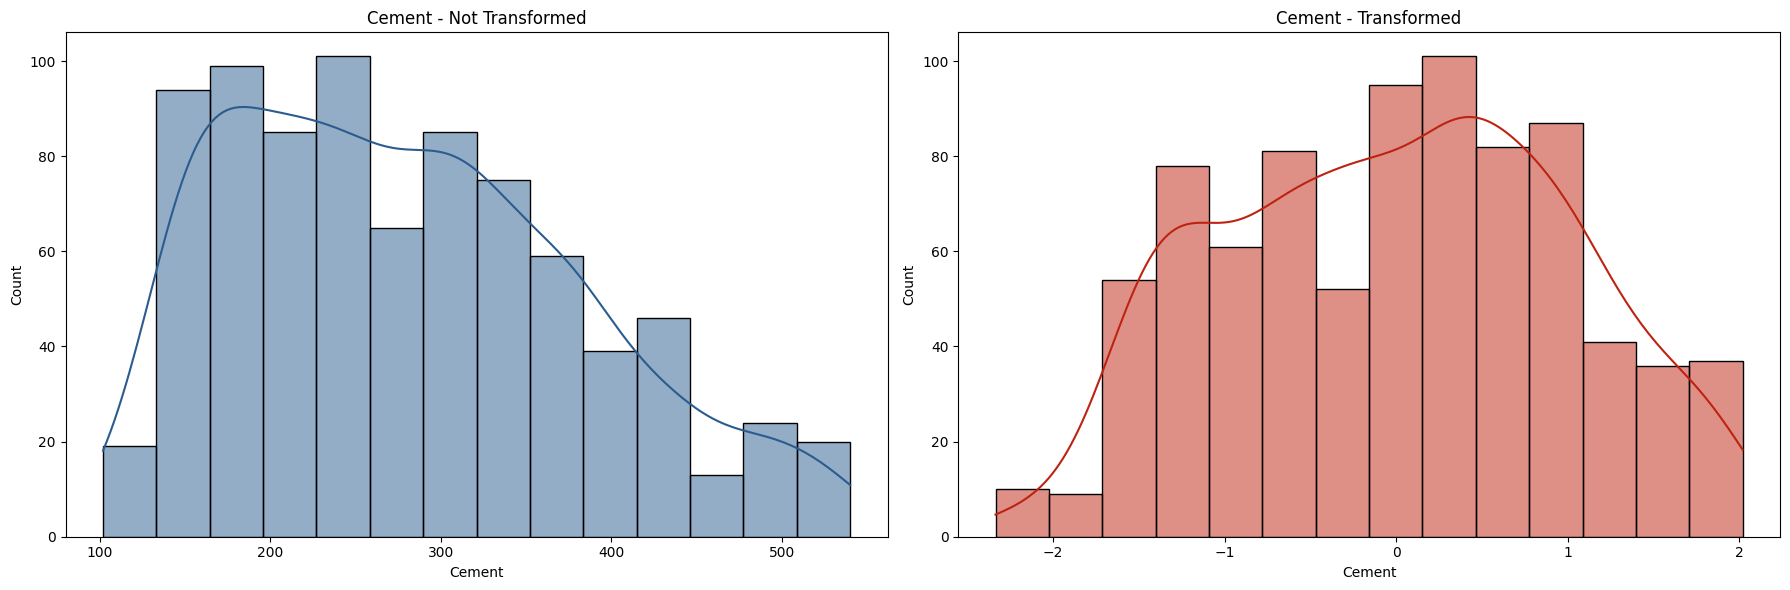

<Figure size 640x480 with 0 Axes>

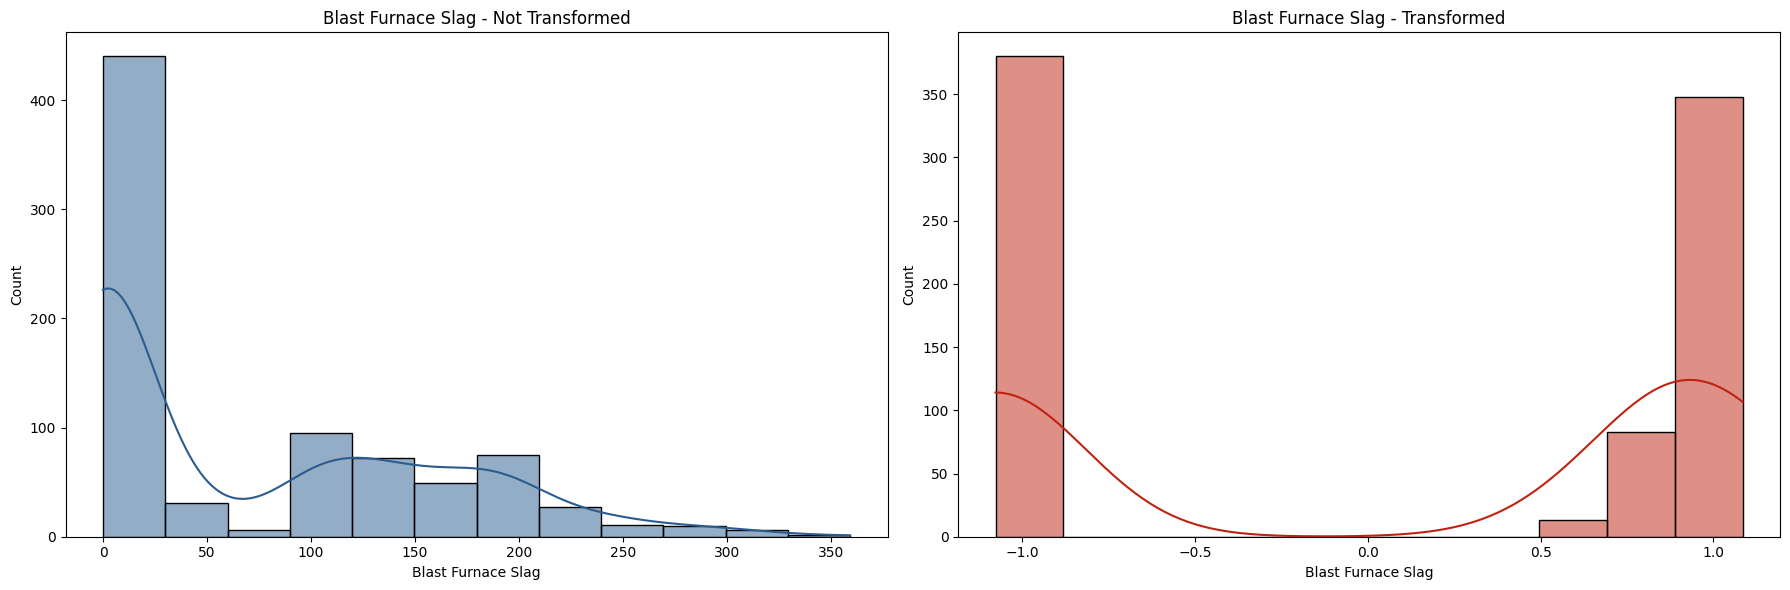

<Figure size 640x480 with 0 Axes>

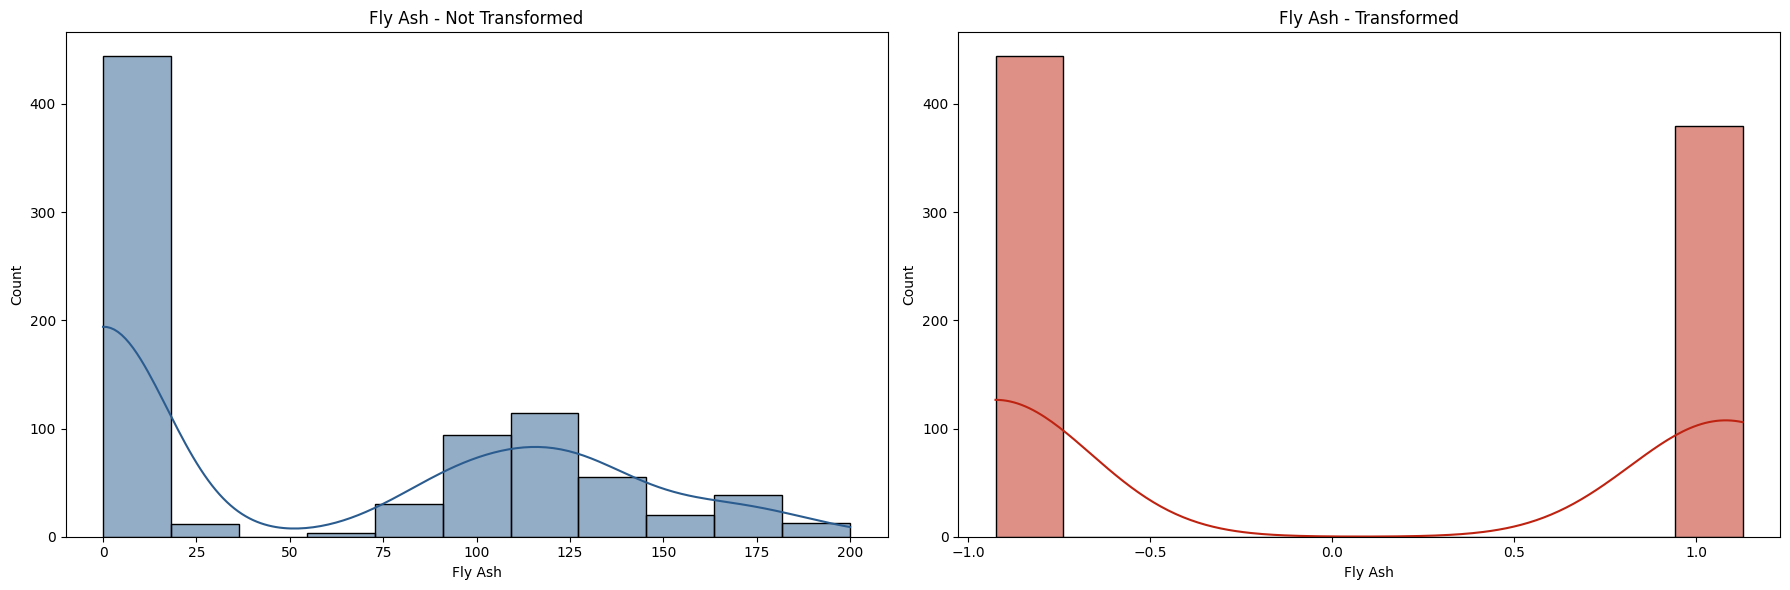

<Figure size 640x480 with 0 Axes>

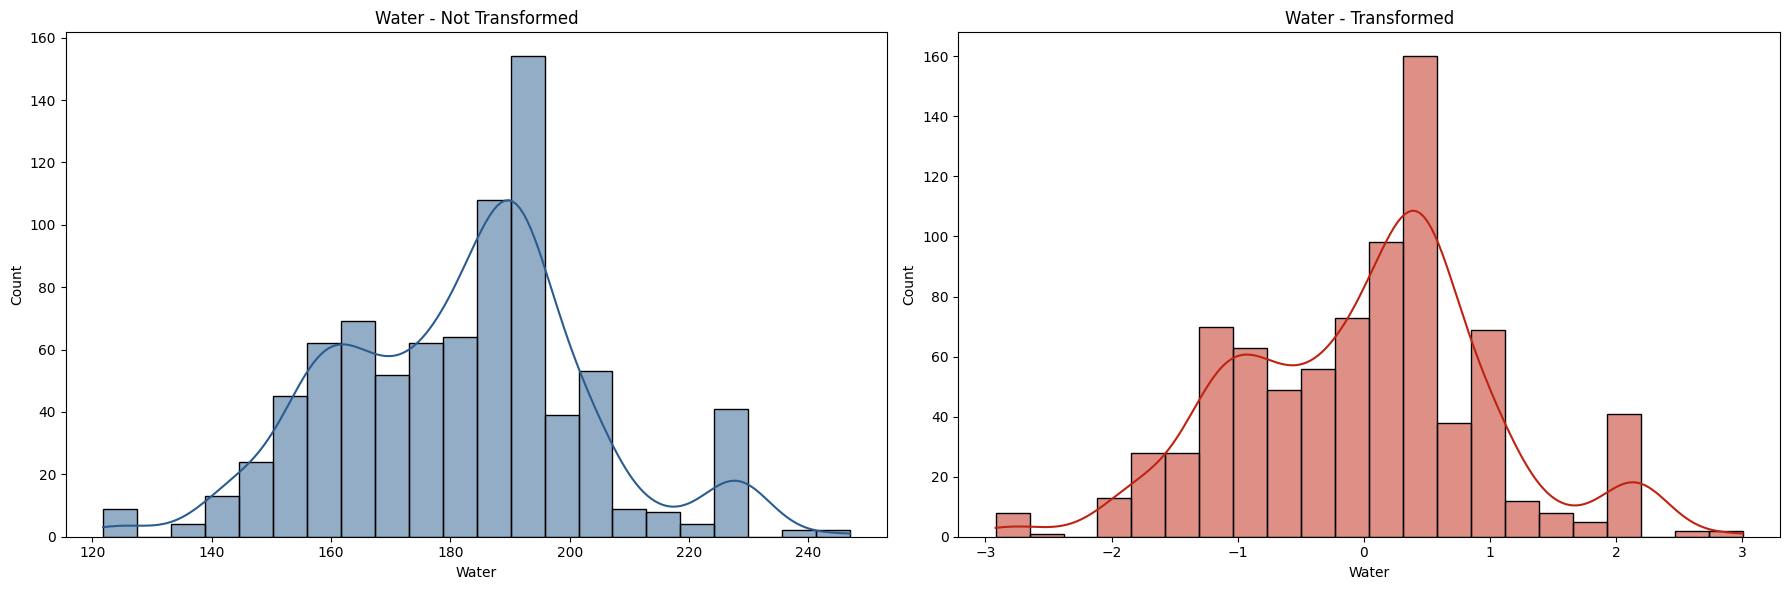

<Figure size 640x480 with 0 Axes>

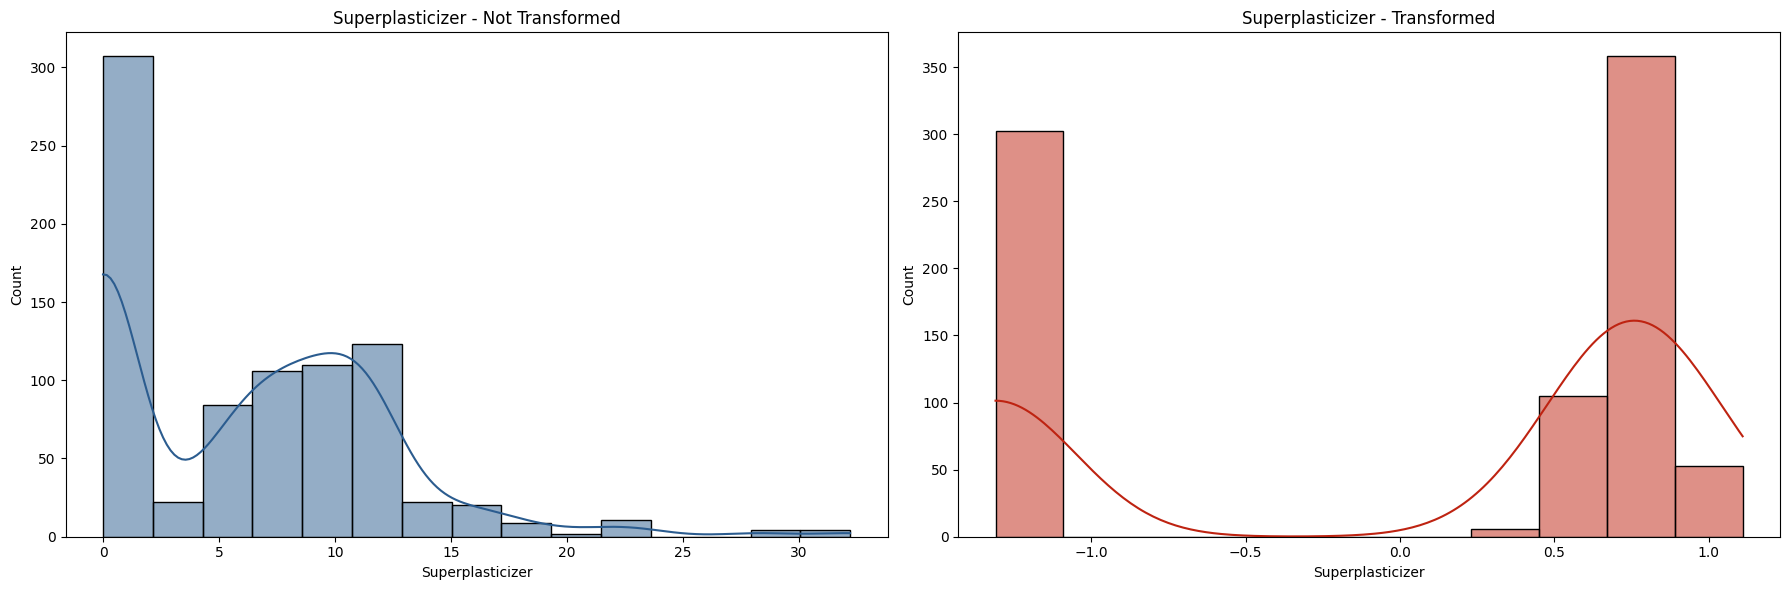

<Figure size 640x480 with 0 Axes>

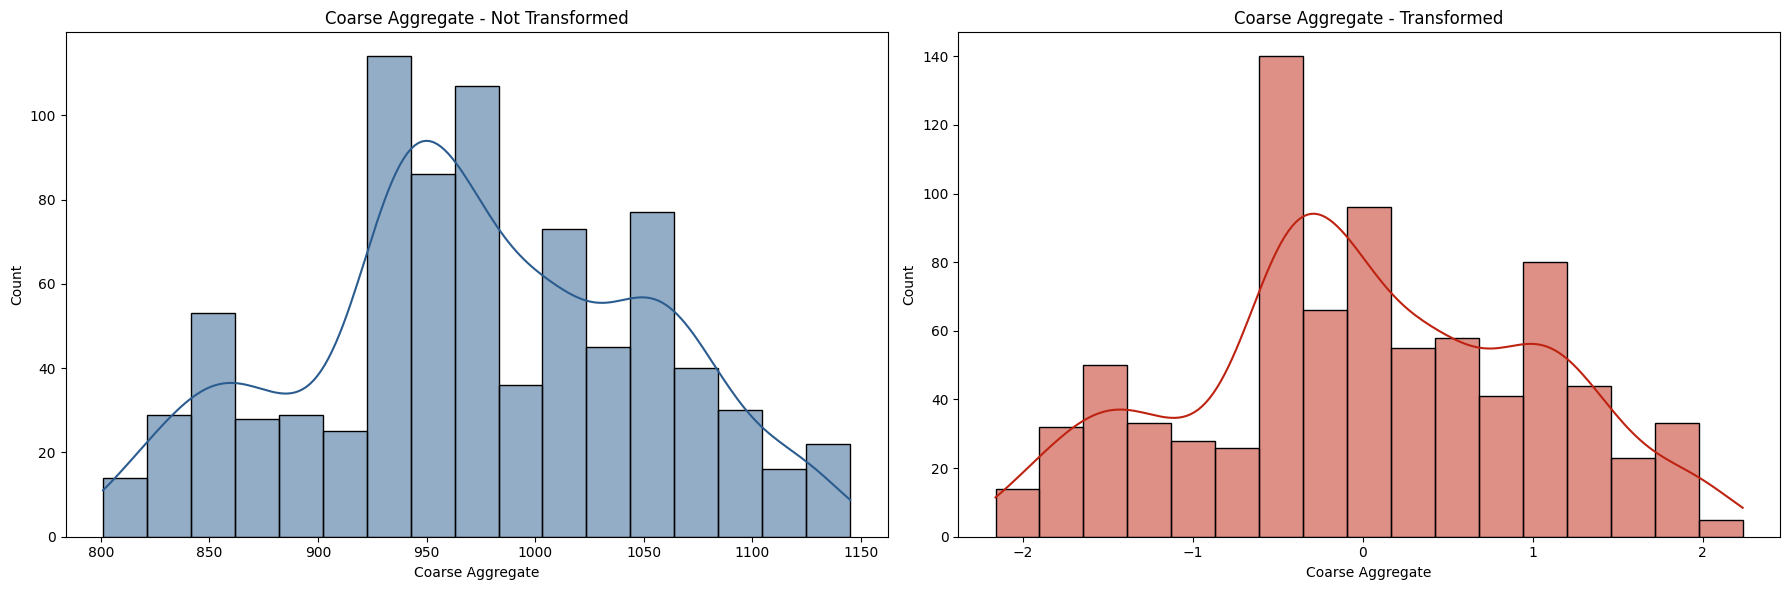

<Figure size 640x480 with 0 Axes>

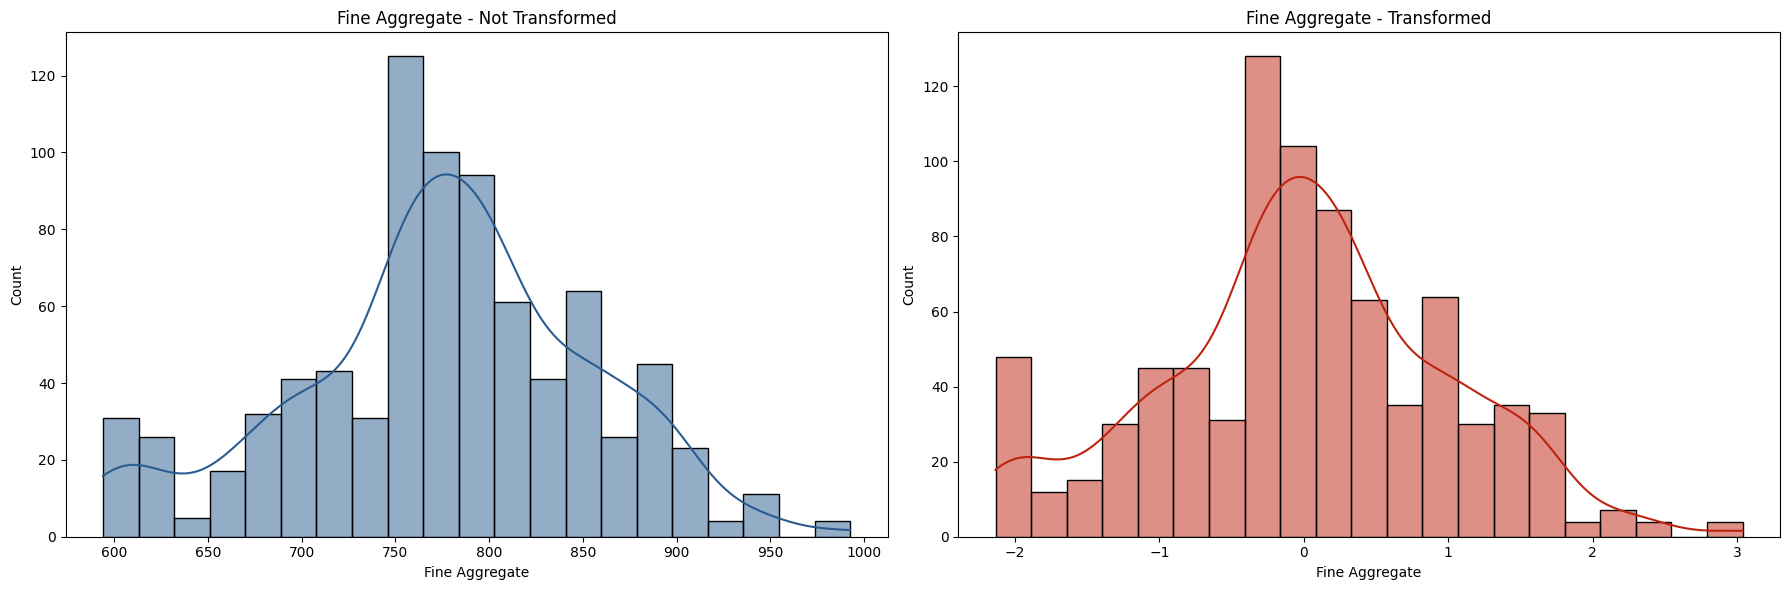

<Figure size 640x480 with 0 Axes>

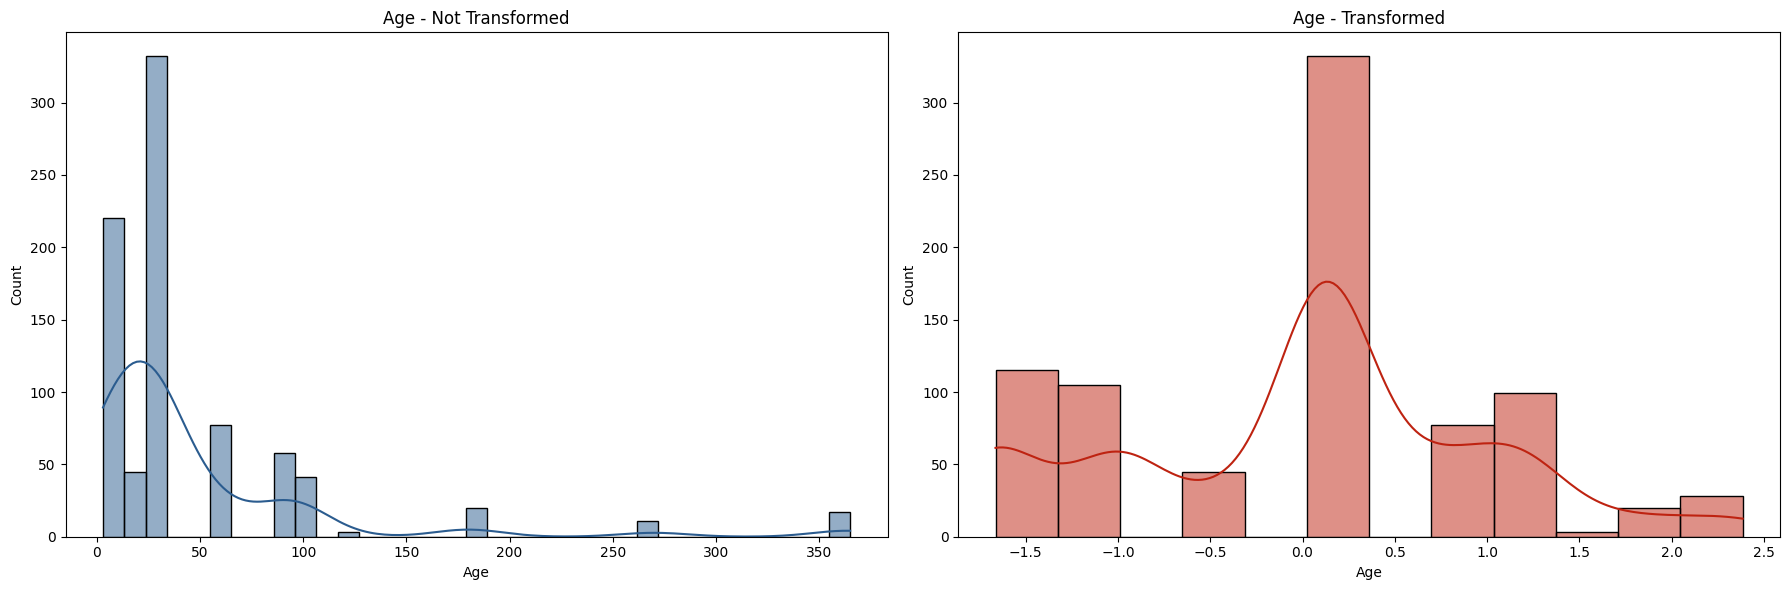

<Figure size 640x480 with 0 Axes>

In [203]:
# Comparing the distplots with and without any transformation
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)


for col in X_train.columns:
    plt.figure(figsize=(18, 6))
    
    # Left Subplot: Before Transformation
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True, color='#2b5c8f')
    plt.title(f"{col} - Not Transformed")
    
    # Right Subplot: After Transformation
    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True, color = '#be2311' )
    plt.title(f"{col} - Transformed")
    
    plt.tight_layout()
    plt.show()
    plt.suptitle("Comparison Before and After Box-Cox Transform",fontsize = 14)

In [204]:
result['Box-Cox'] = [r2_score(y_test,y_pred_boxcox),np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))]

# Yeo-johnson Transform

In [205]:
yj = PowerTransformer() # Yeo-Johnson is default transform

X_train_transformed2 = yj.fit_transform(X_train)
X_test_transformed2 = yj.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)
y_pred_yj = lr.predict(X_test_transformed2)

r2_score(y_test,y_pred_yj)

0.8096608486414492

In [206]:
pd.DataFrame({'cols':X_train.columns,'lambdas' : yj.lambdas_ })

,cols,lambdas
0,Cement,0.178740
1,Blast Furnace Slag,0.006022
2,Fly Ash,-0.110146
3,Water,0.797659
4,Superplasticizer,0.272251
5,Coarse Aggregate,1.171004
6,Fine Aggregate,1.792129
7,Age,-0.007919


In [207]:
#applying cross val
yj = PowerTransformer()
X_yj = yj.fit_transform(X)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_yj,y,scoring='r2'))

np.float64(0.6834625126992435)

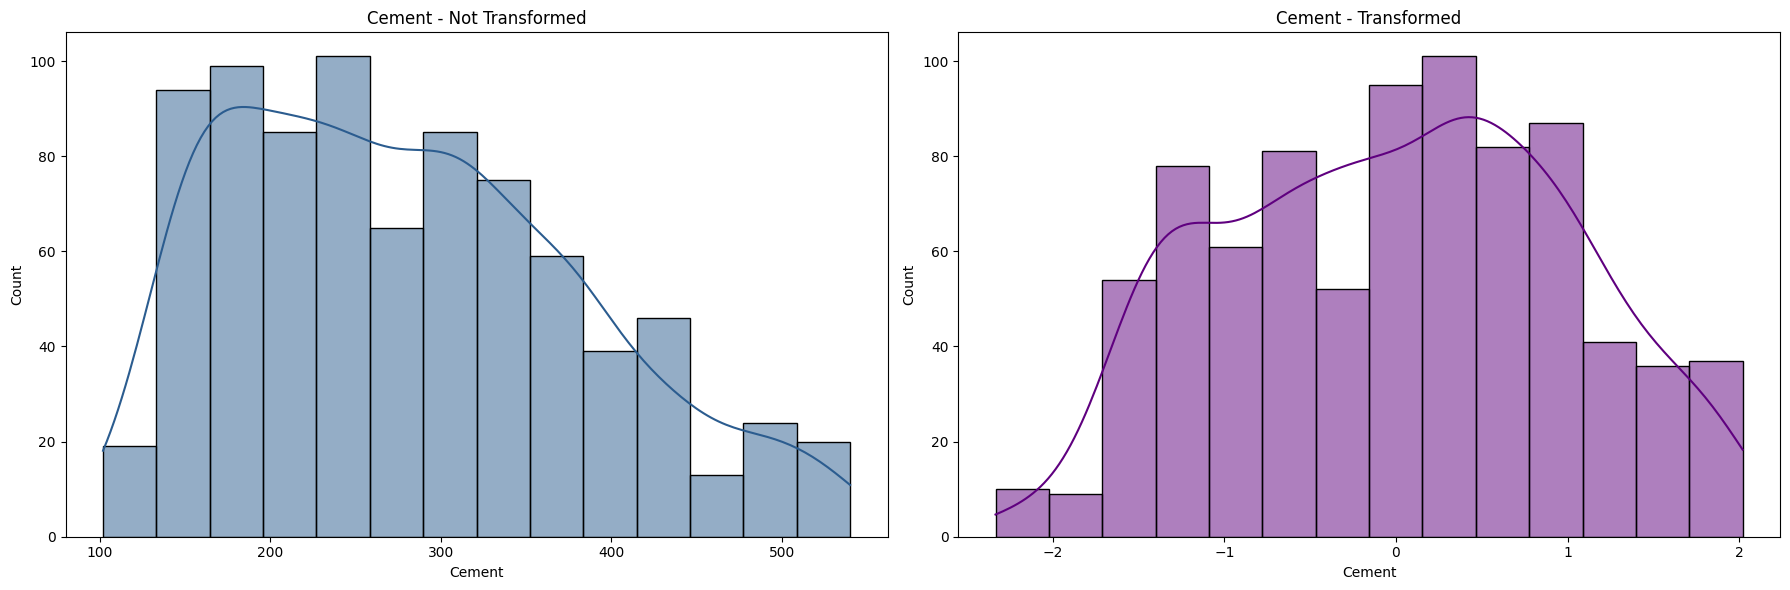

<Figure size 640x480 with 0 Axes>

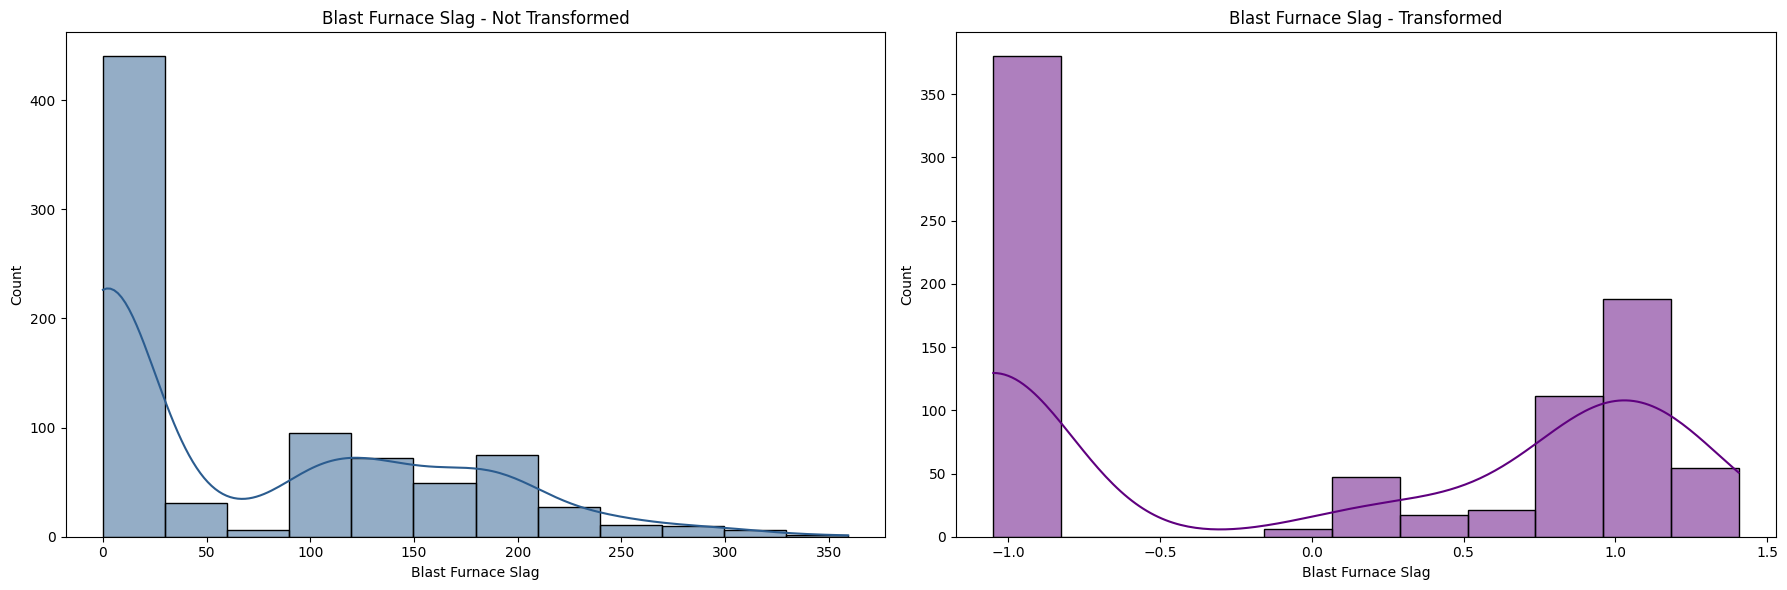

<Figure size 640x480 with 0 Axes>

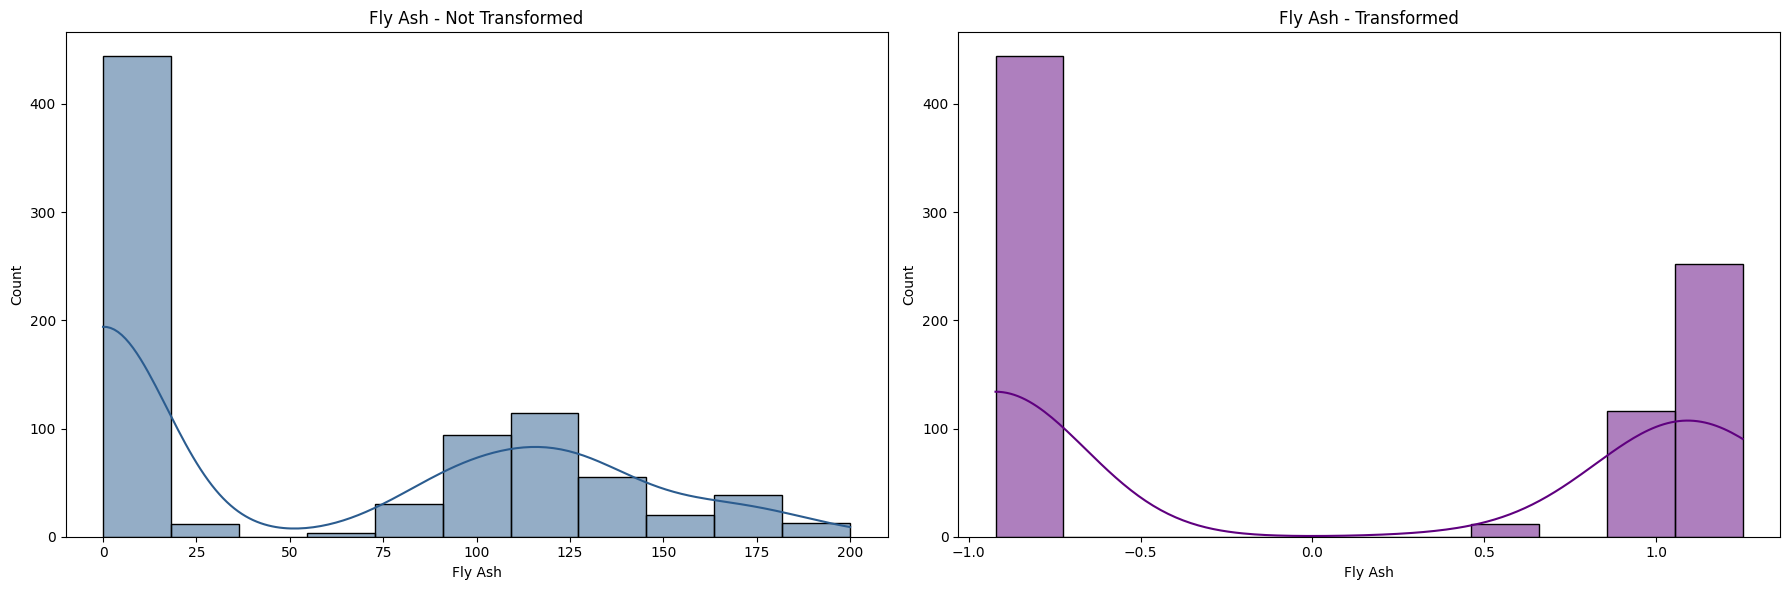

<Figure size 640x480 with 0 Axes>

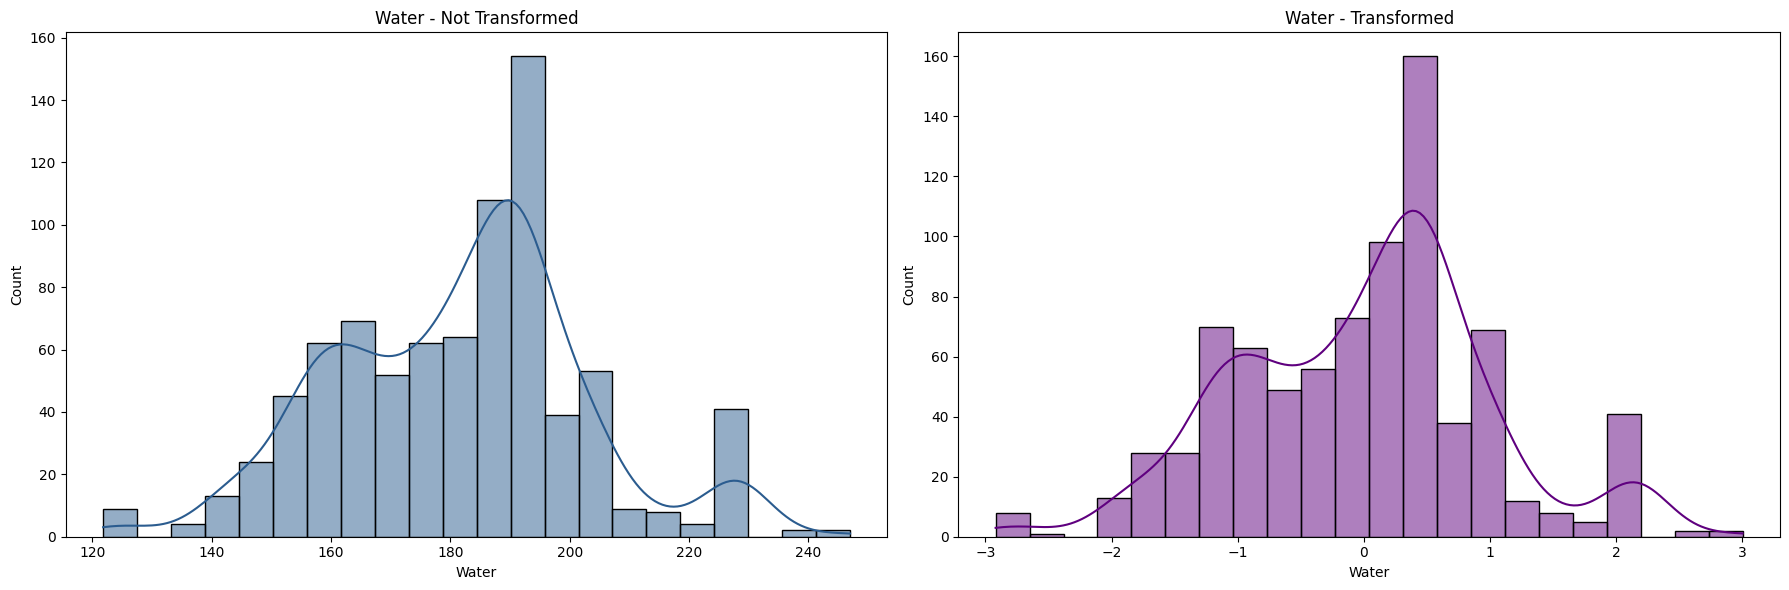

<Figure size 640x480 with 0 Axes>

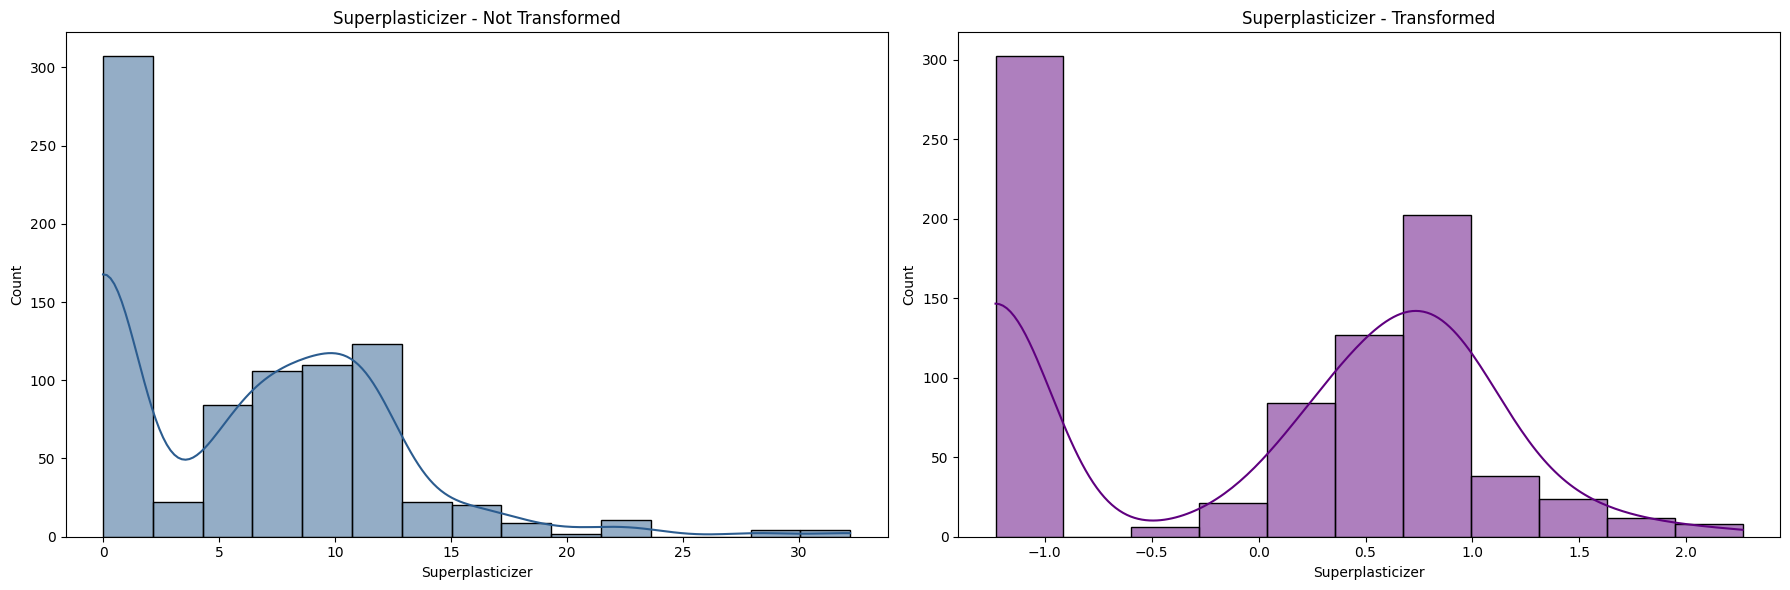

<Figure size 640x480 with 0 Axes>

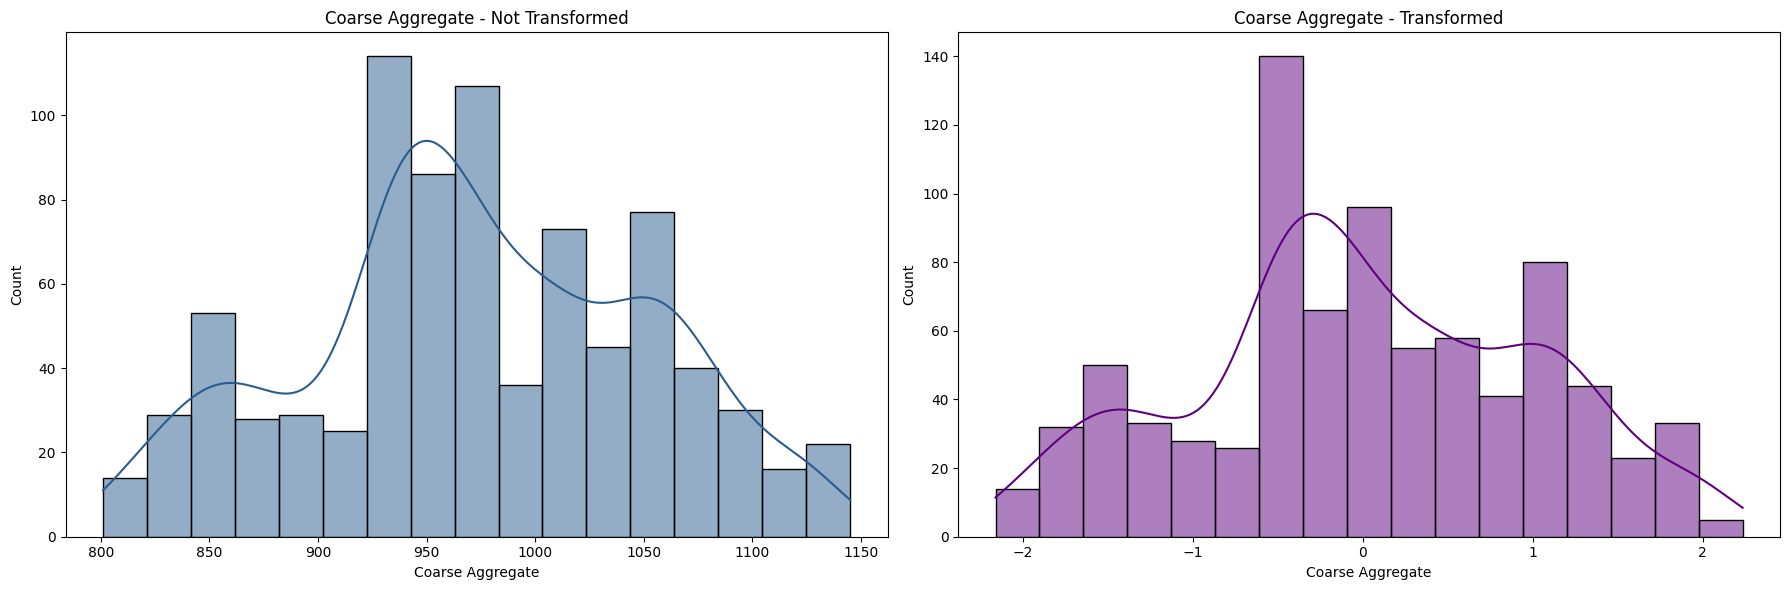

<Figure size 640x480 with 0 Axes>

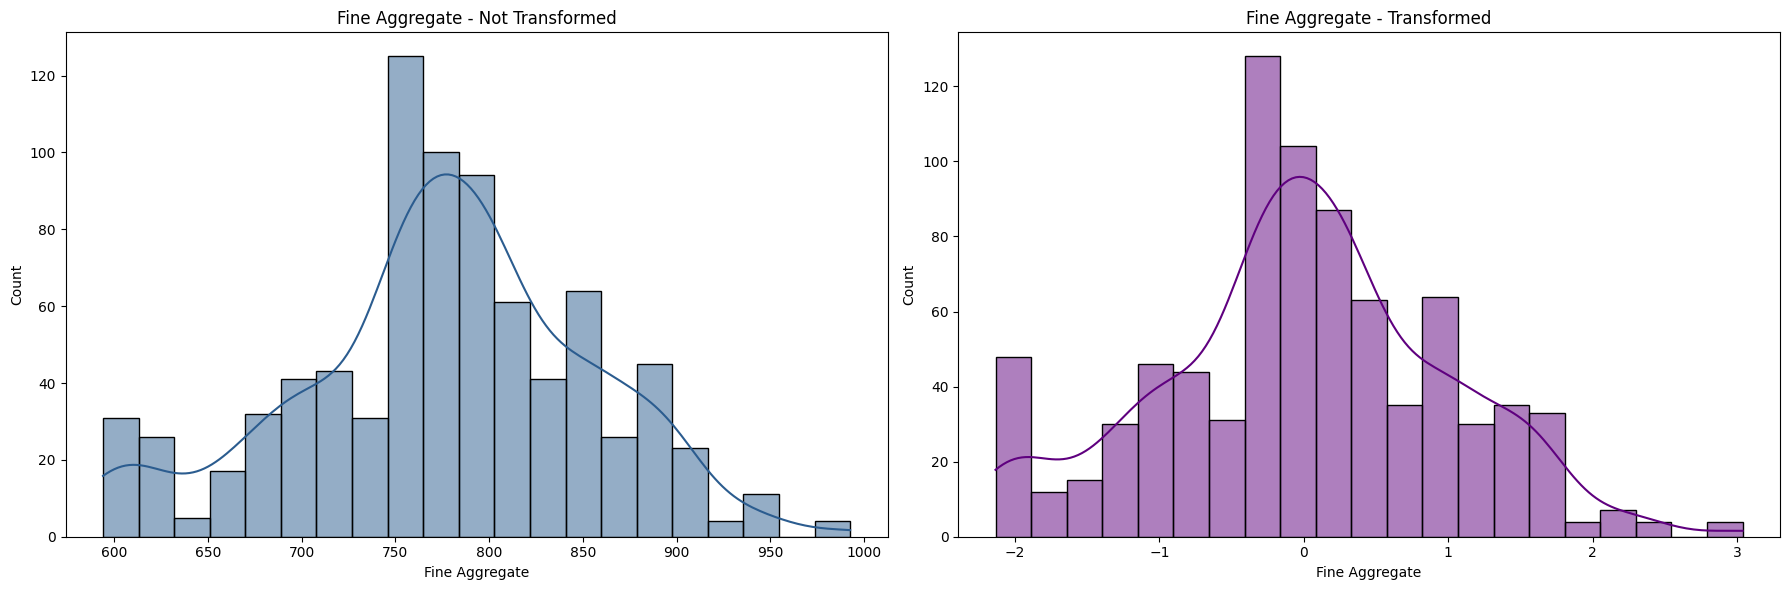

<Figure size 640x480 with 0 Axes>

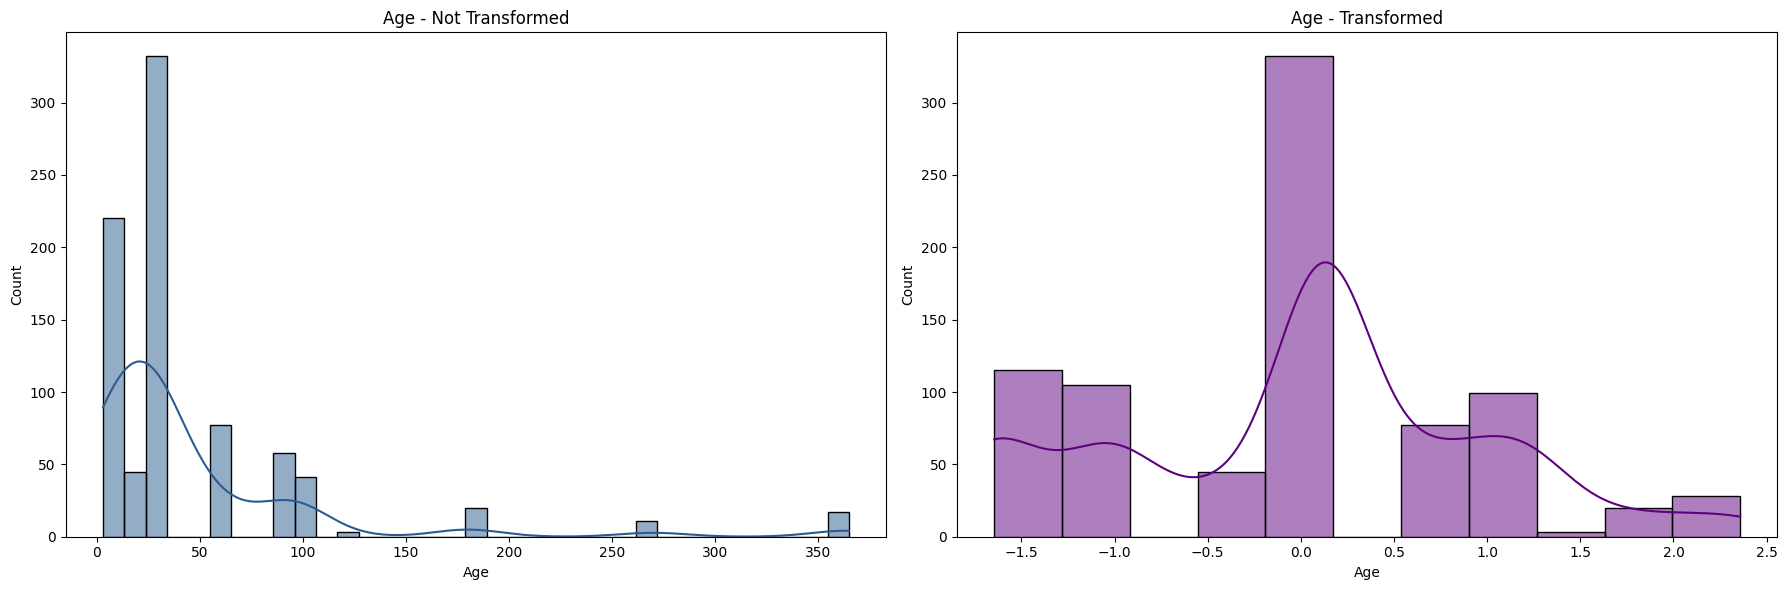

<Figure size 640x480 with 0 Axes>

In [208]:
# Comparing the distplots with and without any transformation
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns= X_train.columns)

for col in X_train.columns:
    plt.figure(figsize=(18, 6))
    
    # Left Subplot: Before Transformation
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True, color='#2b5c8f')
    plt.title(f"{col} - Not Transformed")
    
    # Right Subplot: After Transformation
    plt.subplot(122)
    sns.histplot(X_train_transformed2[col], kde=True, color = '#5f007f' )
    plt.title(f"{col} - Transformed")
    
    plt.tight_layout()
    plt.show()
    plt.suptitle("Comparison Before and After Yeo-Johnson Transform",fontsize = 14)

In [209]:
result['Yeo-Johnson'] = [r2_score(y_test,y_pred_yj),np.mean(cross_val_score(lr,X_yj,y,scoring='r2'))]

In [210]:
pd.DataFrame(result, index=['r2 score','cross_val_r2 score'])

,No Transform,Box-Cox,Yeo-Johnson
r2 score,0.615189,0.809520,0.809661
cross_val_r2 score,0.460994,0.665854,0.683463
